# Combine Two YOLO Models on the Same NFL Frame (No Homography Yet)

This notebook:

- Loads **two trained YOLO models**:
  - A *field model* (detects hashes, numbers, etc.)
  - A *player model* (detects players)
- Runs **both models on the same input image**
- Extracts detections from each
- Combines the outputs into a single Python structure

> This version does **not** do any homography / field-coordinate mapping.  
> It only combines raw pixel-space detections.


In [19]:
import os
import sys
from pathlib import Path

import cv2
import numpy as np
from ultralytics import YOLO

print("Python:", sys.version)
print("CWD:", os.getcwd())

# ========================
# CONFIG: UPDATE THESE PATHS
# ========================

# Path to trained YOLO models
# Make sure these point to your actual best.pt files (usually under runs/train/.../weights/best.pt)
FIELD_MODEL_WEIGHTS = "runs/detect/football_yolo11n2/weights/best.pt"     # field / hash / number model
PLAYER_MODEL_WEIGHTS = "runs/detect/football_positions3/weights/best.pt" # player detector
NUMBER_MODEL_WEIGHTS = "runs/classify/train4/weights/best.pt"

# Path to an example NFL frame
IMAGE_PATH = "data/Football Player Detection.v7i.yolov11/test/images/57506_000286_Sideline_frame193_jpg.rf.cd69aa4f300bd4661fbe46509cc25e93.jpg"  # e.g. "test/images/frame_0001.jpg"

print("Field model weights:", FIELD_MODEL_WEIGHTS)
print("Player model weights:", PLAYER_MODEL_WEIGHTS)
print("Example image path:", IMAGE_PATH)

Python: 3.9.6 (default, Oct 17 2025, 17:15:53) 
[Clang 17.0.0 (clang-1700.4.4.1)]
CWD: /Users/lucaspedemonte/Documents/VSCode/NFL_Play_Classifier/NFL_Play_Outcome_Classifier
Field model weights: runs/detect/football_yolo11n2/weights/best.pt
Player model weights: runs/detect/football_positions3/weights/best.pt
Example image path: data/Football Player Detection.v7i.yolov11/test/images/57506_000286_Sideline_frame193_jpg.rf.cd69aa4f300bd4661fbe46509cc25e93.jpg


In [20]:
# ========================
# Load YOLO Models
# ========================

if not os.path.exists(FIELD_MODEL_WEIGHTS):
    print(f"⚠️ Field model weights not found at: {FIELD_MODEL_WEIGHTS}")
else:
    print(f"✅ Found field model at: {FIELD_MODEL_WEIGHTS}")

if not os.path.exists(PLAYER_MODEL_WEIGHTS):
    print(f"⚠️ Player model weights not found at: {PLAYER_MODEL_WEIGHTS}")
else:
    print(f"✅ Found player model at: {PLAYER_MODEL_WEIGHTS}")

if not os.path.exists(NUMBER_MODEL_WEIGHTS):
    print(f"⚠️ Player model weights not found at: {NUMBER_MODEL_WEIGHTS}")
else:
    print(f"✅ Found player model at: {NUMBER_MODEL_WEIGHTS}")

field_model = YOLO(FIELD_MODEL_WEIGHTS)
player_model = YOLO(PLAYER_MODEL_WEIGHTS)
number_model = YOLO(NUMBER_MODEL_WEIGHTS)

print("Field model classes:", field_model.names)
print("Player model classes:", player_model.names)
print("Number model classes:", number_model.names)

✅ Found field model at: runs/detect/football_yolo11n2/weights/best.pt
✅ Found player model at: runs/detect/football_positions3/weights/best.pt
✅ Found player model at: runs/classify/train4/weights/best.pt
Field model classes: {0: 'ball', 1: 'five_hash', 2: 'hash', 3: 'marker', 4: 'number', 5: 'player', 6: 'pylon', 7: 'ref'}
Player model classes: {0: 'C', 1: 'DB', 2: 'LB', 3: 'QB', 4: 'SKILL'}
Number model classes: {0: '10', 1: '20', 2: '30', 3: '40', 4: '50'}


In [21]:
# ========================
# Helper: Convert YOLO Results to Dicts
# ========================

def extract_detections(result):
    """Convert a YOLO result object into a list of simple dicts.
    
    Each dict:
    {
        'class_id': int,
        'class_name': str,
        'confidence': float,
        'bbox': (x1, y1, x2, y2)
    }
    """
    det_list = []
    names = result.names
    
    for box in result.boxes:
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        
        det_list.append({
            "class_id": cls_id,
            "class_name": names[cls_id],
            "confidence": conf,
            "bbox": (x1, y1, x2, y2),
        })
    return det_list

In [22]:
# ========================
# Run All Models on the Same Image
# ========================

# Load the image
img = cv2.imread(IMAGE_PATH)
if img is None:
    raise FileNotFoundError(f"Could not load image at: {IMAGE_PATH}")

# ------------------------
# 1. Run the field model
# ------------------------
print("Running field model...")
field_results = field_model(img)[0]   # first (and only) image in batch
field_dets = extract_detections(field_results)
print(f"Field detections: {len(field_dets)}")

# Add yard-number classification for 'number' detections
for det in field_dets:
    if "number" not in det["class_name"].lower():
        continue

    x1, y1, x2, y2 = map(int, det["bbox"])
    crop_bgr = img[y1:y2, x1:x2]
    if crop_bgr.size == 0:
        continue

    crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)

    # classify with number model
    r = number_model(crop_rgb)[0]
    cls_id = int(r.probs.top1)
    yard_label = number_model.names[cls_id]
    conf = float(r.probs.top1conf)

    # attach prediction to this detection
    det["yard_number_pred"] = yard_label
    det["yard_number_conf"] = conf

# ------------------------
# 2. Run the player model
# ------------------------
print("\nRunning player model...")
player_results = player_model(img)[0]
player_dets = extract_detections(player_results)
print(f"Player detections: {len(player_dets)}")

# ------------------------
# 3. Combine outputs
# ------------------------
combined_output = {
    "field": field_dets,    # now includes yard_number_pred/conf on number boxes
    "players": player_dets,
}

combined_output

Running field model...



0: 736x1280 6 five_hashs, 28 hashs, 6 numbers, 71.9ms
Speed: 1.5ms preprocess, 71.9ms inference, 0.5ms postprocess per image at shape (1, 3, 736, 1280)
Field detections: 40

0: 64x64 30 0.89, 20 0.11, 40 0.00, 10 0.00, 50 0.00, 1.4ms
Speed: 0.4ms preprocess, 1.4ms inference, 0.0ms postprocess per image at shape (1, 3, 64, 64)

0: 64x64 50 0.92, 40 0.07, 30 0.00, 10 0.00, 20 0.00, 1.2ms
Speed: 0.5ms preprocess, 1.2ms inference, 0.0ms postprocess per image at shape (1, 3, 64, 64)

0: 64x64 30 0.71, 20 0.21, 50 0.05, 10 0.02, 40 0.00, 1.5ms
Speed: 0.6ms preprocess, 1.5ms inference, 0.0ms postprocess per image at shape (1, 3, 64, 64)

0: 64x64 40 1.00, 50 0.00, 30 0.00, 10 0.00, 20 0.00, 1.2ms
Speed: 0.5ms preprocess, 1.2ms inference, 0.0ms postprocess per image at shape (1, 3, 64, 64)

0: 64x64 40 0.60, 10 0.12, 30 0.11, 50 0.08, 20 0.08, 1.3ms
Speed: 0.4ms preprocess, 1.3ms inference, 0.0ms postprocess per image at shape (1, 3, 64, 64)

0: 64x64 20 0.45, 50 0.25, 30 0.17, 10 0.12, 40 0.0

{'field': [{'class_id': 1,
   'class_name': 'five_hash',
   'confidence': 0.8688977360725403,
   'bbox': (4.755973815917969,
    456.4041748046875,
    37.96910858154297,
    463.67144775390625)},
  {'class_id': 1,
   'class_name': 'five_hash',
   'confidence': 0.8590110540390015,
   'bbox': (663.1051025390625,
    490.4033203125,
    694.6729736328125,
    497.242431640625)},
  {'class_id': 4,
   'class_name': 'number',
   'confidence': 0.8207787275314331,
   'bbox': (298.02935791015625,
    180.39736938476562,
    447.4671630859375,
    224.49362182617188),
   'yard_number_pred': '30',
   'yard_number_conf': 0.8895576000213623},
  {'class_id': 1,
   'class_name': 'five_hash',
   'confidence': 0.7050471901893616,
   'bbox': (68.82797241210938,
    346.4163818359375,
    100.14315795898438,
    355.0572509765625)},
  {'class_id': 2,
   'class_name': 'hash',
   'confidence': 0.578685998916626,
   'bbox': (749.3115234375,
    375.61358642578125,
    762.1123046875,
    389.44354248046875

Combined detections summary:
{'field': [{'bbox': (4.755973815917969,
                     456.4041748046875,
                     37.96910858154297,
                     463.67144775390625),
            'class_id': 1,
            'class_name': 'five_hash',
            'confidence': 0.8688977360725403},
           {'bbox': (663.1051025390625,
                     490.4033203125,
                     694.6729736328125,
                     497.242431640625),
            'class_id': 1,
            'class_name': 'five_hash',
            'confidence': 0.8590110540390015},
           {'bbox': (298.02935791015625,
                     180.39736938476562,
                     447.4671630859375,
                     224.49362182617188),
            'class_id': 4,
            'class_name': 'number',
            'confidence': 0.8207787275314331,
            'yard_number_conf': 0.8895576000213623,
            'yard_number_pred': '30'},
           {'bbox': (68.82797241210938,
                     3

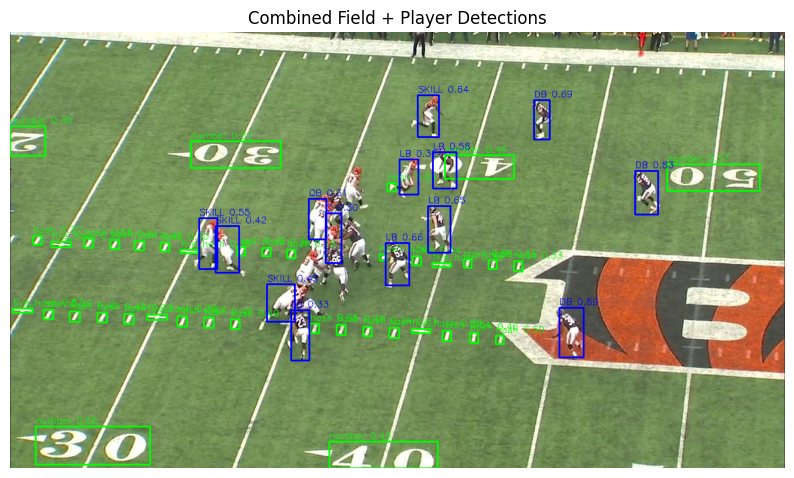

In [ ]:
# ========================
# Optional: Pretty Print & Visualize Detections
# ========================

from pprint import pprint
import matplotlib.pyplot as plt

print("Combined detections summary:")
pprint(combined_output)

# Draw both sets of detections on the image for visualization
vis = img.copy()

# Draw field detections in one color
# Draw field detections in green
for det in combined_output["field"]:
    x1, y1, x2, y2 = map(int, det["bbox"])

    # If this is a 'number' and we have classifier output, show that
    if "number" in det["class_name"].lower() and "yard_number_pred" in det:
        label = f"{det['yard_number_pred']} ({det['yard_number_conf']:.2f})"
    else:
        # Fallback: original YOLO label
        label = f"{det['class_name']} ({det['confidence']:.2f})"

    cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(
        vis,
        label,
        (x1, max(0, y1 - 5)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 255, 0),
        2
    )

# Draw player detections in another color
for det in combined_output["players"]:
    x1, y1, x2, y2 = map(int, det["bbox"])
    label = f"{det['class_name']} {det['confidence']:.2f}"
    cv2.rectangle(vis, (x1, y1), (x2, y2), (255, 0, 0), 2)
    cv2.putText(vis, label, (x1, max(y1 - 5, 0)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)

# Convert BGR (OpenCV) -> RGB (matplotlib)
vis_rgb = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(vis_rgb)
plt.axis("off")
plt.title("Combined Field + Player Detections")
plt.show()

## Next Steps

From here you can:

- Loop over many frames and collect `combined_output` into a list or a CSV.
- Add homography later to convert pixel `(x, y)` centers into field coordinates in yards.
- Use the combined detections as input features to your **play outcome classifier**.

To adapt this to a folder of images, you can replace `IMAGE_PATH` with a loop over a directory:
```python
from glob import glob

for path in glob("frames/*.jpg"):
    # run the same pipeline on each image
    ...
```